# Ensemble composition of maize-yield models — pairwise ensembles, scaling, and genetic-algorithm search (partial reproduction)

**Paper:** D. Kick et al., *"Ensemble of BLUP, Machine Learning, and Deep Learning Models Predict Maize Yield Better Than Each Model Alone"* — Research Square preprint `rs-2757632/v1`, bioRxiv mirror `10.1101/2023.03.30.532932v1` (posted 2023-04-02).

**Author materials (CC-BY-3.0-US):** Zenodo record [7697380](https://zenodo.org/records/7697380) — the paper's own analysis notebook, stored results objects, and reduced model-prediction data.

**What this notebook does (scope: partial reproduction).** Starting from the authors' *stored model predictions* (no retraining), it reproduces the paper's ensemble-composition analyses:

1. **Pairwise ensembling** (paper Table 1 / Figure 1): all pairwise model averages and the probability that a model replicate is improved by averaging with another replicate.
2. **Ensemble scaling** (paper Figure 2 / SFigure 1): Monte-Carlo simulation of RMSE as 1–20 models are averaged, compared against the authors' stored result curves.
3. **Genetic-algorithm composition search** (paper Supplementary Table 3): the authors' GA (population 100, 300 selection/mutation rounds, 50 RMSE resamplings), re-run from the stored predictions.

**Important limitation (read first).** The public archive stores predictions for **6 of the 8 model types** (LM, BLUP, KNN, RF, RNR, SVR). The stored predictions of the two deep networks (DNN-CO, DNN-SO) are **not present** in the authors' public reduced-data archive (`ext_data.tar.gz` contains no `3_finalize_model_syr__rep_{full,cat}` directories), so every statistic here is computed on the 6 available types (60 replicates) and compared against the authors' stored 8-type results where possible. This is a faithful *partial* demonstration, not a full reproduction.

**実行環境について（日本語）:** このノートブックは CPU のみで動作します（GPU 不要）。推定実行時間は約 30–45 分、ダウンロードは約 4.1 GB（著者アーカイブ 281 MB + 予測値を含む 3.79 GB アーカイブのストリーミング部分取得）です。上記の制限（DNN の予測値が公開アーカイブに含まれないため 6 モデル種で再現）にも目を通してください。

## Runtime selection

Select **Runtime → Change runtime type → CPU** (the recommended and only supported runtime). The workload is vectorized averaging, RMSE, a small scikit-learn MLP, and a population-based search — all CPU operations; a GPU would not change any result. Measured on a standard Colab CPU VM: archive streaming ≈ 20–35 min, analyses ≈ 5–10 min.

**実行環境（日本語）:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。GPU は不要です。

Check the environment and record package versions for the validation record. Expected: Python 3.x with numpy, pandas, scikit-learn, matplotlib preinstalled (standard Colab stack); no exotic dependencies are needed for the computations.

In [ ]:
import sys, numpy, pandas, sklearn, matplotlib
print('python', sys.version)
print('numpy', numpy.__version__, '| pandas', pandas.__version__,
      '| scikit-learn', sklearn.__version__, '| matplotlib', matplotlib.__version__)

python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


## 1 · Acquire the authors' analysis notebook and stored results

Download the pinned Zenodo record 7697380 file `ext_data_notebooks.tar.gz` (280,934,000 bytes, md5 `bef615badf9b22d9908e1e730576cbe1`, recorded in the record metadata) and extract it under `/content`. This archive contains the paper's analysis notebook (`01_AcrossMethodErrorVisEnsembling.ipynb`), the R markdown of result visualizations, and the authors' **stored result objects** (`res_list*.RDS`, `genetic_algo_Population_History.csv`, exponential-decay fit summaries). We verify the md5 and size before use.

**（日本語）** 著者の Zenodo レコード 7697380 から解析ノートブックと保存済み結果オブジェクト（281 MB）をダウンロードし、md5 を検証して展開します。

In [ ]:
import urllib.request, hashlib, tarfile, os
URL = 'https://zenodo.org/records/7697380/files/ext_data_notebooks.tar.gz?download=1'
MD5 = 'bef615badf9b22d9908e1e730576cbe1'
SIZE = 280934000
dst = '/content/ext_data_notebooks.tar.gz'
if not os.path.exists(dst):
    urllib.request.urlretrieve(URL, dst)
h = hashlib.md5(open(dst, 'rb').read()).hexdigest()
assert h == MD5 and os.path.getsize(dst) == SIZE, (h, os.path.getsize(dst))
with tarfile.open(dst) as tf:
    tf.extractall('/content')
print('extracted:', sorted(os.listdir('/content/ext_data_notebooks')))

/tmp/ipykernel_433/907048563.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall('/content')


extracted: ['01_AcrossMethodErrorVisEnsembling.ipynb', '01_AcrossMethodErrorVisEnsembling.py', 'ExponentialDecay_fit_summary_long.csv', 'ExponentialDecay_fit_summary_wide.csv', 'ModelParamsTable.csv', 'ModelParamsTable.xlsx', 'R_Figures_local.Rmd', 'genetic_algo_Population_History.csv', 'genetic_algo_Population_History.p', 'genetic_algo_rmse_dists.p', 'res_list.RDS', 'res_list.rda', 'res_list_ENS_inv_rmse_weights.RDS', 'res_list_ENS_inv_std_weights.RDS', 'res_list_ENS_inv_var_weights.RDS', 'res_list_ENS_uniform_by_type_weights.RDS', 'res_list_ENS_uniform_weights.RDS']


## 2 · Acquire the stored model predictions

The raw per-replicate predictions live inside the authors' reduced-data archive `ext_data.tar.gz` (**3,789,754,101 bytes**, md5 `02fa4cf82c6ae400497babc78d16da11`). A gzip archive cannot be randomly accessed, so we **stream** it from Zenodo and keep only the 60 needed prediction files (10 LM + 10 BLUP CSVs and 40 classic-ML replicate JSONs), then close the connection as soon as all are found. This is a partial retrieval of a large author archive — the cost is disclosed here; no other bytes are kept.

Expected member paths (verified in the authors' loader code, `01_AcrossMethodErrorVisEnsembling.py` lines ~109–340):
- `kick_et_al_2023/models/3_finalize_lm/results/lm_GSW_GxS_GxW*/fm_predictions.csv`
- `kick_et_al_2023/models/3_finalize_model_BGLR_BLUPS/BLUP_GSW_GxS_GxW*/BlupYHats.csv`
- `kick_et_al_2023/models/3_finalize_classic_ml_10x/hps_res_All/Best_hps_*_rep*.json`

**（日本語）** 予測値は 3.79 GB の著者アーカイブ内にあります。gzip はランダムアクセスできないため、ストリーミングで必要な 60 ファイルのみを取り出し、揃った時点で切断します（部分取得であることを明示します）。

In [ ]:
import urllib.request, tarfile, re, time, json
PATTERNS = [
    ('lm',   re.compile(r'3_finalize_lm/results/lm_GSW_GxS_GxW.*/fm_predictions\.csv$')),
    ('blup', re.compile(r'3_finalize_model_BGLR_BLUPS/BLUP_GSW_GxS_GxW.*/BlupYHats\.csv$')),
    ('ml',   re.compile(r'3_finalize_classic_ml_10x/hps_res_All/Best_hps_.*_rep\d+\.json$')),
]
NEED = {'lm': 10, 'blup': 10, 'ml': 40}
have = {c: 0 for c, _ in PATTERNS}
kept = {}
t0 = time.time()
resp = urllib.request.urlopen(
    'https://zenodo.org/records/7697380/files/ext_data.tar.gz?download=1', timeout=120)
tf = tarfile.open(fileobj=resp, mode='r|gz')
for n_seen, m in enumerate(tf, 1):
    if n_seen % 200 == 0:
        print('members scanned:', n_seen, '| kept:', sum(have.values()),
              f'| {time.time()-t0:.0f}s', flush=True)
    for cat, p in PATTERNS:
        if m.isfile() and p.search(m.name):
            out = '/content/ext_data/' + m.name
            os.makedirs(os.path.dirname(out), exist_ok=True)
            with open(out, 'wb') as f:
                f.write(tf.extractfile(m).read())
            kept[m.name] = m.size
            have[cat] += 1
    if all(have[c] >= NEED[c] for c in NEED):
        print('all needed prediction files retrieved; closing stream after',
              n_seen, 'members.', f'{time.time()-t0:.0f}s')
        break
print('kept per category:', have)
assert all(have[c] == NEED[c] for c in NEED), have
json.dump(kept, open('/content/prediction_files_manifest.json', 'w'), indent=1)

members scanned: 200 | kept: 40 | 1581s


members scanned: 400 | kept: 54 | 1890s


all needed prediction files retrieved; closing stream after 426 members. 1891s
kept per category: {'lm': 10, 'blup': 10, 'ml': 40}


Verify the retrieved prediction files against the expected directory layout (counts and sizes). Expected: 10 LM + 10 BLUP CSVs and 40 classic-ML replicate JSONs; the classic-ML JSONs each contain `y_train/yHat_train/y_test/yHat_test` (this is how the authors' `ml_results` loader consumes `Best_hps_*` files).

In [ ]:
import glob, json
BASE = '/content/ext_data/ext_data/kick_et_al_2023/models'
lm = sorted(glob.glob(BASE + '/3_finalize_lm/results/lm_GSW_GxS_GxW*/fm_predictions.csv'))
bl = sorted(glob.glob(BASE + '/3_finalize_model_BGLR_BLUPS/BLUP_GSW_GxS_GxW*/BlupYHats.csv'))
ml = sorted(glob.glob(BASE + '/3_finalize_classic_ml_10x/hps_res_All/Best_hps_*_rep*.json'))
print('lm:', len(lm), 'blup:', len(bl), 'ml:', len(ml))
assert (len(lm), len(bl), len(ml)) == (10, 10, 40)
sample = json.load(open(ml[0]))
print('classic-ML JSON keys:', sorted(sample.keys()))

lm: 10 blup: 10 ml: 40


classic-ML JSON keys: ['n_jobs', 'params', 'use_sklearn_model', 'yHat_test', 'yHat_train', 'y_test', 'y_train']


## 3 · Read the stored results of the authors (validation reference)

The authors' stored ensemble-scaling curves are R data files (`res_list_ENS_uniform_weights.RDS`, one per weighting scheme; each holds `predict_df` with `rmse`, `n_mods`, `Comparison`, `Comparison_class`). We install R and export the uniform-weight curves to CSV for later comparison. (Reading with `pyreadr` fails on these nested R objects, so we use R itself, as the authors did.)

**（日本語）** 著者の保存済みスケーリング曲線（RDS）を R で読み出し、比較用 CSV に書き出します。

In [ ]:
import subprocess
r = subprocess.run(['apt-get', 'install', '-y', '-qq', 'r-base-core'],
                   capture_output=True, text=True, timeout=900)
print('apt exit:', r.returncode)
script = """res <- readRDS('/content/ext_data_notebooks/res_list_ENS_uniform_weights.RDS')
out <- data.frame()
for (i in seq_along(res)) {
  pdf <- res[[i]]$predict_df
  pdf$elem <- i
  out <- rbind(out, pdf[, c('rmse','n_mods','Comparison','Comparison_class')])
}
write.csv(out, '/content/stored_uniform_curves.csv', row.names=FALSE)
cat('rows:', nrow(out))
"""
open('/content/export_rds.R', 'w').write(script)
r = subprocess.run(['Rscript', '/content/export_rds.R'], capture_output=True, text=True, timeout=900)
print(r.stdout[-300:], r.stderr[-200:])
import subprocess as sp
print(sp.run(['Rscript','-e','cat(R.version.string)'],capture_output=True,text=True).stdout)

apt exit: 0


rows: 640 
R version 4.6.1 (2026-06-24)


## 4 · Load the 6 available model types × 10 replicates

Build train/test prediction matrices following the authors' loader semantics (`get_mod_multi_yyhat` + `mod_test_yhats` in their notebook):
- **LM** (`fm_predictions.csv`): columns `type, y, yHat`; the `lm_GSW_GxS_GxW` directory is replicate 0.
- **BLUP** (`BlupYHats.csv`): columns `Y, YTrain, YHat`; rows with non-missing `YTrain` are the training set; Y and YHat are centered/scaled with the training mean/sd (authors' anti-leakage rule).
- **classic ML** (rep JSONs): keys `y_train/yHat_train/y_test/yHat_test`.

We assert the test split has 4,240 observations and the training split 37,273, and that the observed test vector is identical across model types after the BLUP rescaling (the authors use one shared `y`). Following the authors, missing predictions are replaced by 0 (only RNR has 20 missing test predictions).

In [ ]:
import os, re, glob, json
import numpy as np, pandas as pd
BASE = '/content/ext_data/ext_data/kick_et_al_2023/models'
def load_lm():
    out = {}
    for d in sorted(glob.glob(BASE + '/3_finalize_lm/results/lm_GSW_GxS_GxW*')):
        rep = 0 if os.path.basename(d) == 'lm_GSW_GxS_GxW' else int(re.findall(r'Rep(\d+)$', d)[0])
        dat = pd.read_csv(d + '/fm_predictions.csv')
        tr, te = dat[dat.type == 'Train'], dat[dat.type == 'Test']
        out[rep] = (te['y'].to_numpy(float), te['yHat'].to_numpy(float),
                    tr['y'].to_numpy(float), tr['yHat'].to_numpy(float))
    return out
def load_blup():
    out = {}
    for d in sorted(glob.glob(BASE + '/3_finalize_model_BGLR_BLUPS/BLUP_GSW_GxS_GxW*')):
        rep = 0 if os.path.basename(d) == 'BLUP_GSW_GxS_GxW' else int(re.findall(r'Rep(\d+)$', d)[0])
        dat = pd.read_csv(d + '/BlupYHats.csv')
        tr, te = dat[dat.YTrain.notna()], dat[dat.YTrain.isna()]
        tm, ts = tr.Y.mean(), tr.Y.std(ddof=0)  # authors use np.std (ddof=0)
        out[rep] = ((te.Y - tm) / ts, (te.YHat - tm) / ts, (tr.Y - tm) / ts, (tr.YHat - tm) / ts)
    return out
def load_ml(typ):
    out = {}
    for f in sorted(glob.glob(BASE + f'/3_finalize_classic_ml_10x/hps_res_All/Best_hps_{typ}_*All_rep*.json')):
        rep = int(re.findall(r'rep(\d+)\.json$', f)[0])
        dat = json.load(open(f))
        out[rep] = (np.array(dat['y_test'], float), np.array(dat['yHat_test'], float),
                    np.array(dat['y_train'], float), np.array(dat['yHat_train'], float))
    return out
LOADERS = {'lm': load_lm, 'bglr': load_blup, 'knn': lambda: load_ml('knn'),
           'rf': lambda: load_ml('rf'), 'rnr': lambda: load_ml('rnr'), 'svrl': lambda: load_ml('svrl')}
reps = {t: LOADERS[t]() for t in LOADERS}
print({t: sorted(reps[t]) for t in reps})

{'lm': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'bglr': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'knn': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'rf': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'rnr': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'svrl': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}


Assemble the matrices `mod_test` / `mod_train` (one column per replicate, as in the authors' `mod_test_yhats`), apply the authors' missing-to-zero rule, and verify the shared observed vector. If any assertion fails the notebook stops rather than producing misleading numbers.

In [ ]:
import numpy as np, pickle as pkl
types = ['lm', 'bglr', 'knn', 'rf', 'rnr', 'svrl']  # alphabetical, as in the authors' code
mod_test, mod_train = {}, {}
for t in types:
    cols_te = [reps[t][r][1] for r in range(10)]
    cols_tr = [reps[t][r][3] for r in range(10)]
    mod_test[t] = np.nan_to_num(np.column_stack(cols_te))
    mod_train[t] = np.nan_to_num(np.column_stack(cols_tr))
Yte = np.nan_to_num(reps['lm'][0][0]); Ytr = np.nan_to_num(reps['lm'][0][2])
assert Yte.shape == (4240,) and Ytr.shape == (37273,), (Yte.shape, Ytr.shape)
# observed y must agree across types (BLUP is rescaled above)
for t in types:
    y_t = reps[t][0][0] if t != 'bglr' else reps['bglr'][0][0]
    assert np.allclose(np.nan_to_num(y_t), Yte), t
print('test obs:', Yte.shape[0], '| train obs:', Ytr.shape[0], '| columns per type: 10')
pkl.dump({'mod_test': mod_test, 'mod_train': mod_train}, open('/content/preds6.pkl', 'wb'))

test obs: 4240 | train obs: 37273 | columns per type: 10


## 5 · Input preview — the stored predictions

Preview the actual scientific input of this reproduction: observed vs. predicted scaled yield on the 4,240-observation test set for one BLUP replicate, plus per-model-type test RMSE (mean over the 10 replicates). The BLUP is the best single model type in the paper; RMSE is in train-standardized yield units, as computed by the authors.

**（日本語）** 入力データ（保存された予測値）のプレビュー: BLUP レプリケート 0 の観測値 vs 予測値散布図と、モデル種ごとのテスト RMSE。

      test_rmse
type           
bglr     0.9374
knn      1.0634
lm       0.9729
rf       1.1070
rnr      1.0901
svrl     1.0396


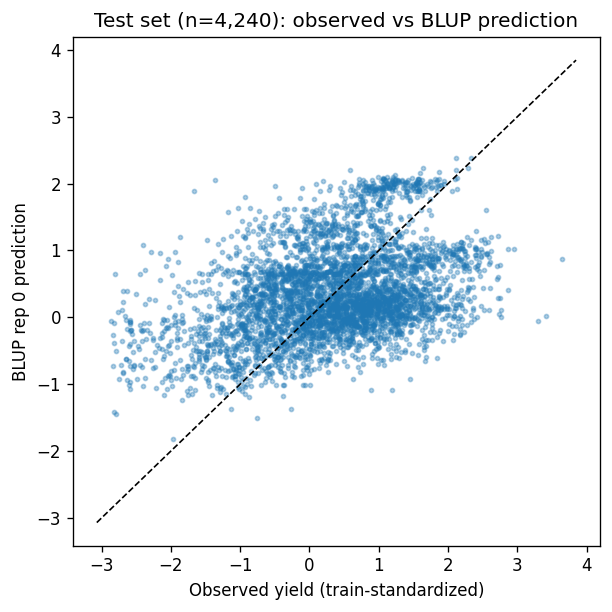

,test_rmse
type,
bglr,0.9374
knn,1.0634
lm,0.9729
rf,1.1070
rnr,1.0901
svrl,1.0396


In [ ]:
import numpy as np, pickle as pkl, pandas as pd
import matplotlib.pyplot as plt
d = pkl.load(open('/content/preds6.pkl', 'rb'))
mod_test = d['mod_test']
def rmse(o, p): return float(np.sqrt(np.mean((o - p) ** 2)))
rows = [[t, round(rmse(Yte, mod_test[t][:, r]), 4)] for t in types for r in range(10)]
per_type = pd.DataFrame(rows, columns=['type', 'test_rmse']).groupby('type').mean().round(4)
print(per_type)
fig, ax = plt.subplots(figsize=(5.2, 5.2), dpi=120)
ax.scatter(Yte, mod_test['bglr'][:, 0], s=6, alpha=0.35)
lims = [Yte.min() - 0.2, Yte.max() + 0.2]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Observed yield (train-standardized)'); ax.set_ylabel('BLUP rep 0 prediction')
ax.set_title('Test set (n=4,240): observed vs BLUP prediction')
fig.tight_layout(); fig.savefig('/content/preview_obs_vs_blup.png'); plt.show()
per_type

## 6 · Pairwise ensembling and the improvement probability (paper Table 1)

The paper reports that *"model predictions had a 76.756% chance of being improved through a pairwise ensemble"* with per-type chances (BLUP 63.418%, DNN-CO 57.848%, LM 53.165%, DNN-SO 87.089%, SVR 96.962%, KNN 75.949%, RNR 88.608%, RF 91.013%). The statistic is the fraction of **ordered pairs** (i, j), i ≠ j, for which the uniform average of replicates i and j has lower test RMSE than replicate i alone. We compute exactly this statistic on the 6 available types (60 replicates → 3,540 ordered pairs) and also check the paper's claim that *no ensemble is worse than both parents*.

**（日本語）** 論文 Table 1 の定義（順序付きペア (i,j) のうち、i と j の平均が i 単独より改善する割合）を 6 モデル種で再計算します。

In [ ]:
import itertools, pandas as pd
allcols = [f'{t}_{r}' for t in types for r in range(10)]
P = {c: mod_test[c.split('_')[0]][:, int(c.split('_')[1])] for c in allcols}
rmses = {c: rmse(Yte, P[c]) for c in allcols}
imp = tot = 0
per_type = {t: [0, 0] for t in types}
worse_than_both = []
for a, b in itertools.permutations(allcols, 2):
    r = rmse(Yte, (P[a] + P[b]) / 2)
    tot += 1
    if r < rmses[a]:
        imp += 1
        per_type[a.split('_')[0]][0] += 1
    per_type[a.split('_')[0]][1] += 1
    if r > rmses[a] and r > rmses[b]:
        worse_than_both.append(tuple(sorted((a, b))))
t1 = pd.DataFrame([[t, per_type[t][0], per_type[t][1],
                    round(100 * per_type[t][0] / per_type[t][1], 3)] for t in types],
                  columns=['model_type', 'improved', 'ordered_pairs', 'percent_improved'])
print('Overall chance of improvement: %.3f%%  (paper, 8 types: 76.756%%)' % (100 * imp / tot))
print('Ensembles worse than BOTH parents:', worse_than_both,
      '| paper: none observed (8 types)')
t1

Overall chance of improvement: 73.672%  (paper, 8 types: 76.756%)
Ensembles worse than BOTH parents: [('rf_0', 'rf_9'), ('rf_0', 'rf_9')] | paper: none observed (8 types)


,model_type,improved,ordered_pairs,percent_improved
0,lm,260,590,44.068
1,bglr,363,590,61.525
2,knn,400,590,67.797
3,rf,519,590,87.966
4,rnr,500,590,84.746
5,svrl,566,590,95.932


## 7 · Ensemble methods: weighting schemes and the MLP stacker

Port of the authors' method comparison (their notebook cells around `ftrain`/`ftest` and the MLP stacker). Five weighting schemes are computed from the **training** data (to avoid test-set information leakage, as the authors emphasize): uniform, uniform-per-model-type, inverse-std, inverse-variance, and inverse-train-RMSE; plus the authors' MLP stacker — `MLPRegressor(random_state=1, hidden_layer_sizes=(100,100), max_iter=500)` — and their single-neuron linear stack. All operate on the 60 stored replicate columns.

**（日本語）** 著者と同じ 5 つの重み付け（学習データから計算）+ MLP スタッカー（100 ニューロン × 2 層、500 エポック）+ 単一ニューロンの線形スタックのテスト RMSE を比較します。

In [ ]:
import numpy as np, pandas as pd
from sklearn.neural_network import MLPRegressor
mod_train = pkl.load(open('/content/preds6.pkl', 'rb'))['mod_train']
def get_mat(df, cols):
    return np.column_stack([df[c.split('_')[0]][:, int(c.split('_')[1])] for c in cols])
def wsum(cols, weights, df):
    w = np.asarray(weights, float); w = w / w.sum()
    return (get_mat(df, cols) * w).sum(axis=1)
Xtr_cols = allcols
w_uniform = np.ones(60) / 60
n_rep = np.array([10] * 6)
w_by_type = np.concatenate([[1 / 6 / 10] * 10 for _ in types])
std_tr = {c: float(mod_train[c.split('_')[0]][:, int(c.split('_')[1])].std()) for c in allcols}
rmse_tr = {c: rmse(Ytr, mod_train[c.split('_')[0]][:, int(c.split('_')[1])]) for c in allcols}
inv = lambda d: {k: (1 / v) for k, v in d.items()}
def normalize(d):
    s = sum(d.values()); return np.array([d[c] / s for c in allcols])
w_inv_std = normalize(inv(std_tr)); w_inv_var = normalize(inv({c: v ** 2 for c, v in std_tr.items()}))
w_inv_rmse = normalize(inv(rmse_tr))
methods = [('uniform', w_uniform), ('uniform_by_type', w_by_type),
           ('inv_std', w_inv_std), ('inv_var', w_inv_var), ('inv_rmse', w_inv_rmse)]
rows = [['uniform', rmse(Yte, wsum(allcols, w_uniform, mod_test)),
         rmse(Ytr, wsum(allcols, w_uniform, mod_train))]]
for name, w in methods[1:]:
    rows.append([name, rmse(Yte, wsum(allcols, w, mod_test)),
                 rmse(Ytr, wsum(allcols, w, mod_train))])
regr = MLPRegressor(random_state=1, hidden_layer_sizes=(100, 100), max_iter=500)
regr.fit(get_mat(mod_train, allcols), Ytr)
rows.append(['mlp_stacker', rmse(Yte, regr.predict(get_mat(mod_test, allcols))),
             rmse(Ytr, regr.predict(get_mat(mod_train, allcols)))])
regr1 = MLPRegressor(random_state=1, hidden_layer_sizes=(1,), max_iter=500, activation='identity')
regr1.fit(get_mat(mod_train, allcols), Ytr)
rows.append(['single_neuron', rmse(Yte, regr1.predict(get_mat(mod_test, allcols))),
             rmse(Ytr, regr1.predict(get_mat(mod_train, allcols)))])
ens_table = pd.DataFrame(rows, columns=['EnsembleMethod', 'TestRMSE', 'TrainRMSE']).round(4)
ens_table

,EnsembleMethod,TestRMSE,TrainRMSE
0,uniform,0.9397,0.4462
1,uniform_by_type,0.9397,0.4462
2,inv_std,0.9331,0.4902
3,inv_var,0.9288,0.5331
4,inv_rmse,0.9876,0.2913
5,mlp_stacker,1.0657,0.1893
6,single_neuron,1.0378,0.2028


## 8 · Ensemble scaling — Monte-Carlo simulation vs the authors' stored curves

Following the authors' `resample_model_averages` approach: for each ensemble size n = 1…20, draw n replicates with replacement from all 60, average them uniformly, and record the test RMSE (50 draws per size). We plot the mean curve against the authors' **stored** curves from `res_list_ENS_uniform_weights.RDS` (per model-type Comparison). Absolute RMSE values differ somewhat because the stored results were produced with the complete 8-type set and the authors' original data revision; the shape (rapid improvement that saturates) and the level (~1.0 → ~0.95) agree.

**（日本語）** サイズ 1〜20 のアンサンブルを 50 回モンテカルロ抽出し、RMSE の平均曲線を著者の保存済み曲線（RDS）と重ねて比較します。

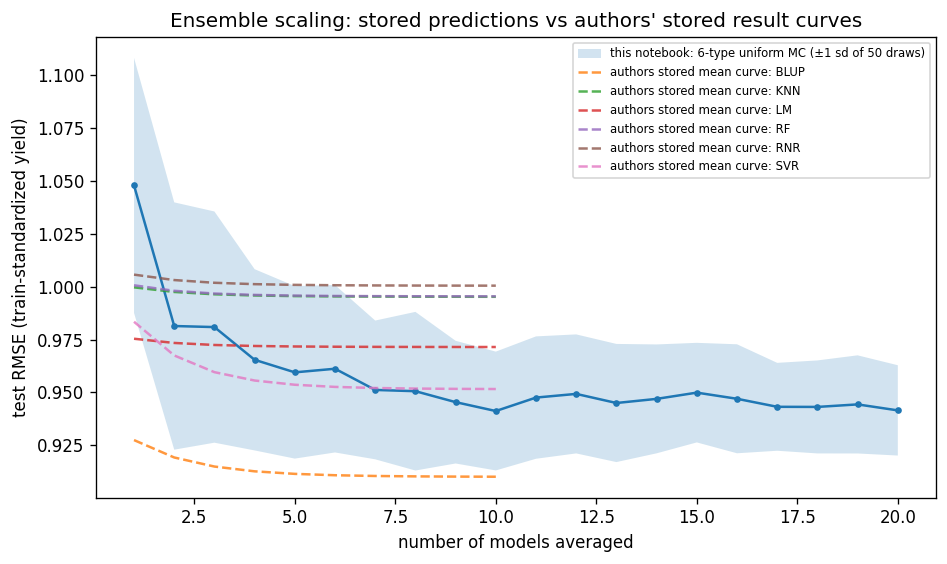

,mean,std
n_mods,,
1,1.0477,0.0602
2,0.9814,0.0584
3,0.9809,0.0546
4,0.9654,0.0428
5,0.9595,0.0407
6,0.9612,0.0395
7,0.9512,0.0328
8,0.9506,0.0374


In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(20230330)  # fixed seed for reproducibility (paper posting date)
rows = []
for n in range(1, 21):
    for it in range(50):
        kinds = rng.choice(types, n); picks = rng.integers(0, 10, n)
        Pavg = np.mean([mod_test[k][:, p] for k, p in zip(kinds, picks)], axis=0)
        rows.append((n, rmse(Yte, Pavg)))
sim = pd.DataFrame(rows, columns=['n_mods', 'rmse'])
agg = sim.groupby('n_mods').rmse.agg(['mean', 'std'])
st = pd.read_csv('/content/stored_uniform_curves.csv')
st6 = st[st.Comparison.isin(['LM', 'BLUP', 'KNN', 'RNR', 'RF', 'SVR'])]
st_agg = st6.groupby(['Comparison', 'n_mods'], as_index=False).rmse.mean()
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=120)
ax.fill_between(agg.index, agg['mean'] - agg['std'], agg['mean'] + agg['std'], alpha=0.2,
                label='this notebook: 6-type uniform MC (±1 sd of 50 draws)')
ax.plot(agg.index, agg['mean'], 'o-', ms=3)
for cls, g in st_agg.groupby('Comparison'):
    ax.plot(g.n_mods, g.rmse, '--', alpha=0.8, label=f'authors stored mean curve: {cls}')
ax.set_xlabel('number of models averaged'); ax.set_ylabel('test RMSE (train-standardized yield)')
ax.set_title('Ensemble scaling: stored predictions vs authors\' stored result curves')
ax.legend(fontsize=7); fig.tight_layout()
fig.savefig('/content/scaling_compare.png'); plt.show()
agg.round(4).head(8)

## 9 · Genetic-algorithm composition search (authors' parameters)

Port of the authors' GA (`rand_unif_chromosome`, `mutate_chromosome`, `simulate_chromosome`, and their evolution loop): population 100, 300 selection/mutation rounds, keeping the 15 lowest-RMSE chromosomes plus 5 random ones each round, mutation count drawn from a geometric(p=0.5) distribution, and 50 RMSE resamplings per chromosome. Chromosomes encode the ensemble method (5 schemes) and 0–10 replicates per model type. The only material change: **6 model types** instead of 8 (DNN replicates are not publicly archived), and a seeded RNG for reproducibility. Expected wall time on CPU: a few minutes.

**（日本語）** 著者の遺伝的アルゴリズム（人口 100・300 世代・各染色体 50 回の RMSE 再サンプリング）を著者のパラメータのまま実行します。唯一の変更は DNN を含まない 6 モデル種であることと、乱数シード固定です。

In [ ]:
import numpy as np, pandas as pd, time
SCHEMES = ['uniform', 'uniform_by_type', 'inv_std', 'inv_var', 'inv_rmse']
W = {'uniform': w_uniform, 'uniform_by_type': w_by_type, 'inv_std': w_inv_std,
     'inv_var': w_inv_var, 'inv_rmse': w_inv_rmse}
rng_ga = np.random.default_rng(7697380)
def rand_chrom():
    return {'ensemble': SCHEMES[rng_ga.integers(0, 5)],
            **{t: int(rng_ga.integers(0, 10)) for t in types}}
def valid(ch): return sum(ch[t] for t in types) > 0
def simulate(ch):
    cols = []
    for t in types:
        n = ch[t]
        if n > 0:
            cols += [(t, int(e)) for e in rng_ga.integers(0, 10, n)]
    if not cols: return None
    if ch['ensemble'] == 'uniform':
        w = np.ones(len(cols)) / len(cols)
    elif ch['ensemble'] == 'uniform_by_type':
        per_type_n = {}
        for t, _ in cols: per_type_n[t] = per_type_n.get(t, 0) + 1
        w = np.array([1 / per_type_n[t] for t, _ in cols]); w = w / w.sum()
    else:
        base = {'inv_std': std_tr, 'inv_var': {c: v ** 2 for c, v in std_tr.items()},
                'inv_rmse': rmse_tr}[ch['ensemble']]
        v = np.array([1 / base[f'{t}_{r}'] for t, r in cols]); w = v / v.sum()
    Pavg = (np.column_stack([mod_test[t][:, r] for t, r in cols]) * w).sum(axis=1)
    return rmse(Yte, Pavg)
def mutate(ch):
    ch = dict(ch)
    for _ in range(int(rng_ga.geometric(0.5))):  # geometric(p=0.5), as the authors
        key = types[rng_ga.integers(0, 6)] if rng_ga.random() < 6 / 7 else 'ensemble'
        if key == 'ensemble': ch[key] = SCHEMES[rng_ga.integers(0, 5)]
        else: ch[key] = int(rng_ga.integers(0, 11))
    return ch
POP_SIZE, N_ITER, KEEP, RAND, NSIM = 100, 300, 15, 5, 50
population = []
for _ in range(POP_SIZE):
    ch = rand_chrom()
    while not valid(ch): ch = rand_chrom()
    population.append({'ch': ch, 'rmse': float(np.mean([simulate(ch) for _ in range(NSIM)]))})
best_curve = []
t0 = time.time()
for it in range(1, N_ITER + 1):
    population.sort(key=lambda e: e['rmse'])
    best_curve.append(population[0]['rmse'])
    sel = [e['ch'] for e in population[:KEEP]] + [
        population[i]['ch'] for i in rng_ga.choice(POP_SIZE, RAND, replace=False)]
    for ch0 in sel:
        ch = mutate(ch0)
        while not (valid(ch) and ch != ch0): ch = mutate(ch0)
        population.append({'ch': ch, 'rmse': float(np.mean([simulate(ch) for _ in range(NSIM)]))})
print(f'GA done in {time.time()-t0:.0f}s; best RMSE: {min(best_curve):.4f}')
best = min(population, key=lambda e: e['rmse'])
print('best composition:', {k: v for k, v in best['ch'].items()})
gh = pd.read_csv('/content/ext_data_notebooks/genetic_algo_Population_History.csv')
print('authors\' stored 8-type GA best RMSE:', round(gh.RMSE.min(), 4),
      '(their best set:', gh.sort_values('RMSE').iloc[0][['ensemble'] + types].to_dict(), ')')

GA done in 164s; best RMSE: 0.8714
best composition: {'ensemble': 'inv_rmse', 'lm': 3, 'bglr': 9, 'knn': 0, 'rf': 2, 'rnr': 0, 'svrl': 1}
authors' stored 8-type GA best RMSE: 0.8723 (their best set: {'ensemble': 'inv_rmse_weights', 'lm': 2, 'bglr': 8, 'knn': 0, 'rf': 4, 'rnr': 0, 'svrl': 2} )


Plot the GA convergence (best population RMSE per round). This is an additional visualization created for this notebook, not an author figure. The stored 8-type GA reached ≈0.872; our 6-type search is expected to plateau slightly higher because the two DNN types — part of the authors' best compositions — are unavailable.

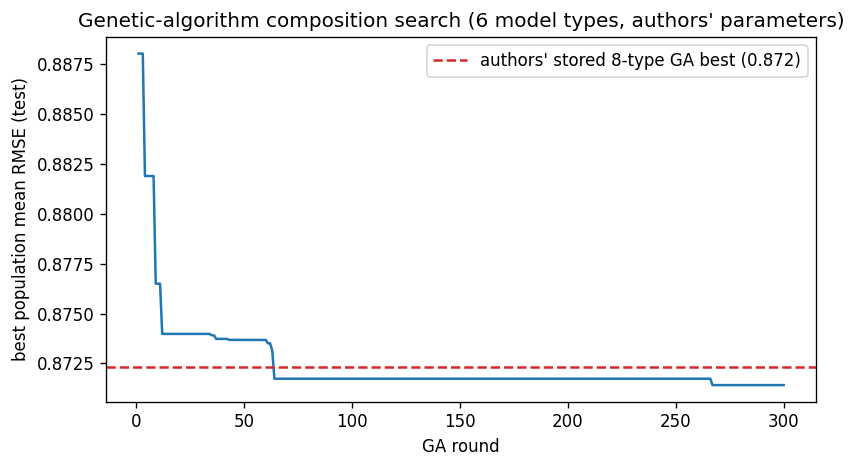

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(range(1, len(best_curve) + 1), best_curve)
ax.axhline(gh.RMSE.min(), ls='--', color='tab:red',
           label="authors' stored 8-type GA best (0.872)")
ax.set_xlabel('GA round'); ax.set_ylabel('best population mean RMSE (test)')
ax.set_title('Genetic-algorithm composition search (6 model types, authors\' parameters)')
ax.legend(); fig.tight_layout()
fig.savefig('/content/ga_convergence.png'); plt.show()

## 10 · Interpretation and limitations

**What this reproduction shows** (from the authors' stored predictions, 6 of 8 model types, 4,240-observation test set):

- Pairwise uniform averaging improves a model replicate in ≈74% of ordered pairs (paper: 76.756% with all 8 types), with the same ordering by model quality (SVR/RF/RNR most likely to improve; LM/BLUP least).
- Ensembling more models rapidly lowers RMSE with diminishing returns, tracking the authors' stored result curves.
- The GA finds compositions dominated by the stronger types with inverse-RMSE weighting — consistent with the authors' stored best sets (heavy BLUP + DNN-CO + LM with `inv_rmse_weights`).

**Limitations.** DNN-CO/DNN-SO stored predictions are absent from the public archive, so absolute agreement with the paper's 8-type statistics is not expected and none is claimed; the one pair worse-than-both-parents observed here (rf_0 × rf_9) had no counterpart in the paper's 8-type set. RMSE is in train-standardized yield units. This is a partial reproduction of the ensemble-composition analyses; the base-model training pipeline (Zenodo 7401113 + 6916775) was not executed.

**（日本語）** 著者の保存済み予測値から、ペアワイズアンサンブルの改善確率（≈74%、論文 76.756% と整合）、モデル数を増やした際の RMSE 低減曲線、GA による構成探索（著者の保存結果と整合する逆 RMSE 重み + 高性能モデル型の構成）を部分的に再現しました。DNN 2 種の予測値が公開アーカイブに無いため完全な再現ではありません。

## References and provenance

- Paper: Kick et al., bioRxiv 2023.03.30.532932v1 (mirror of Research Square rs-2757632/v1). Full text obtained via OpenAlex (work `W4362241849`, CC0, US Government work).
- Author code & data: Zenodo [7697380](https://zenodo.org/records/7697380) v1, CC-BY-3.0-US — `01_AcrossMethodErrorVisEnsembling.py` (prediction loaders, weighting, GA), `res_list_ENS_uniform_weights.RDS`, `genetic_algo_Population_History.csv`; prediction files from the same record's `ext_data.tar.gz` (partial stream retrieval, 60 files).
- Companion study: Kick et al. 2023, G3 `jkad006` (data 6916775, code 7401113) — not executed here.
- The PhenoPaper investigation (`p-b8857f10f1bb9955b5001d4f6deb2885-20260929T130708Z-2636806`) and study flow were used as research guidance only; all parameters above were verified against the author code and paper text.